<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Homework_modul_1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2 \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2 \\
H_1: p_1 > p_2
$$

In [1]:
import math
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.8) -> int:
    """
    Расчёт размера выборки для сравнения двух пропорций (двусторонний тест)
    """
    delta = abs(p2 - p1)
    p_b = (p1 + p2) / 2

    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)

    numerator = (
        z_alpha * (2 * p_b * (1 - p_b)) ** 0.5 +
        z_beta * (p1 * (1 - p1) + p2 * (1 - p2)) ** 0.5
    ) ** 2

    n = numerator / (delta ** 2)

    return math.ceil(n)

In [3]:
p1 = 0.35
p2 = 0.40

n = sample_size_two_proportions(p1, p2)
print(f"Минимальное количество элементов в каждой выборке: {n}")

Минимальное количество элементов в каждой выборке: 1471


Распределение первой пропорции, полученное с помощью ЦПТ:
Математическое ожидание: 0.35
Дисперсия: 0.012436104539810084
Распределение второй пропорции, полученное с помощью ЦПТ:
Математическое ожидание: 0.4
Дисперсия: 0.012773187417058376


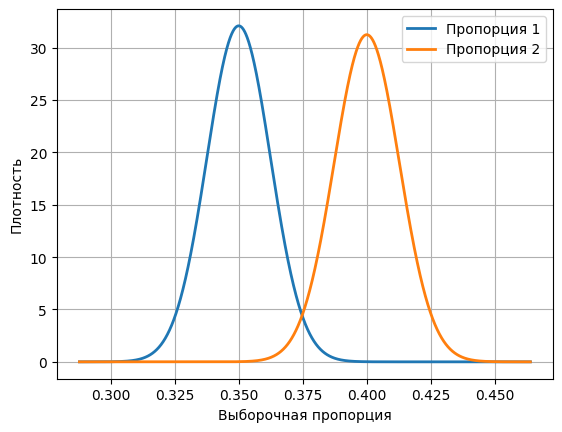

In [26]:
 # Нормальные распределения по ЦПТ для каждой выборки
alpha = 0.05
mu1, mu2 = p1, p2
s1 = math.sqrt(p1 * (1 - p1) / n)
s2 = math.sqrt(p2 * (1 - p2) / n)

print("Распределение первой пропорции, полученное с помощью ЦПТ:")
print("Математическое ожидание:", mu1)
print("Дисперсия:", s1)
print("Распределение второй пропорции, полученное с помощью ЦПТ:")
print("Математическое ожидание:", mu2)
print("Дисперсия:", s2)

# Ось абсцисс

x_min = min(mu1 - 5*s1, mu2 - 5*s2)
x_max = max(mu1 + 5*s1, mu2 + 5*s2)
x = np.linspace(x_min, x_max, 3000)

# Плотности вероятностей

dist1 = norm.pdf(x, loc=mu1, scale=s1)
dist2 = norm.pdf(x, loc=mu2, scale=s2)

plt.plot(x, dist1, label="Пропорция 1", linewidth=2)
plt.plot(x, dist2, label="Пропорция 2", linewidth=2)
plt.xlabel("Выборочная пропорция")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True)

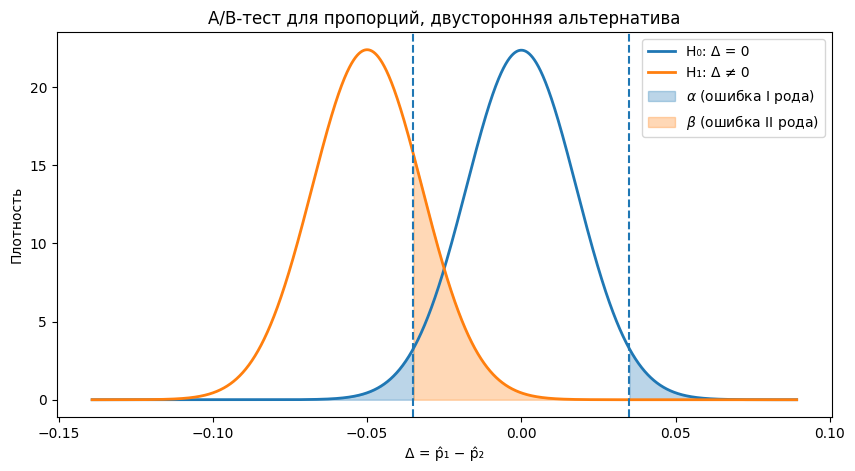

In [19]:
# Параметры распределения статистики для верной H0 (mu1 == mu2)

p_bar = (p1 + p2) / 2
mu_H0 = 0
SE_H0 = math.sqrt(2 * p_bar * (1 - p_bar) / n)

# Параметры распределения статистики для верной H1 (mu1 != mu2)

mu_H1 = p1 - p2
SE_H1 = math.sqrt(p1 * (1 - p1) / n + p2 * (1 - p2) / n)

# Двусторонняя альтернатива

z_two = norm.ppf(1 - alpha/2)
c_left  = -z_two * SE_H0
c_right =  z_two * SE_H0

# Ось абсцисс

x_min = min(mu_H0 - 5*SE_H0, mu_H1 - 5*SE_H1)
x_max = max(mu_H0 + 5*SE_H0, mu_H1 + 5*SE_H1)
x = np.linspace(x_min, x_max, 3000)

# Плотности вероятностей

pdf_H0 = norm.pdf(x, loc=mu_H0, scale=SE_H0)
pdf_H1 = norm.pdf(x, loc=mu_H1, scale=SE_H1)

plt.figure(figsize=(10, 5))

plt.plot(x, pdf_H0, label="H₀: Δ = 0", linewidth=2)
plt.plot(x, pdf_H1, label="H₁: Δ ≠ 0", linewidth=2)

# Критические области

plt.axvline(c_left,  linestyle="--")
plt.axvline(c_right, linestyle="--")

# Ошибка I рода (α)

alpha_color = "tab:blue"

plt.fill_between(
    x[x <= c_left],
    pdf_H0[x <= c_left],
    color=alpha_color,
    alpha=0.3,
    label=r"$\alpha$ (ошибка I рода)"
)

plt.fill_between(
    x[x >= c_right],
    pdf_H0[x >= c_right],
    color=alpha_color,
    alpha=0.3
)

# Ошибка II рода (β)

beta_color = "tab:orange"
mask_beta = (x >= c_left) & (x <= c_right)

plt.fill_between(
    x[mask_beta],
    pdf_H1[mask_beta],
    color=beta_color,
    alpha=0.3,
    label=r"$\beta$ (ошибка II рода)"
)

plt.xlabel("Δ = p̂₁ − p̂₂")
plt.ylabel("Плотность")
plt.title("A/B-тест для пропорций, двусторонняя альтернатива")
plt.legend()
plt.show()

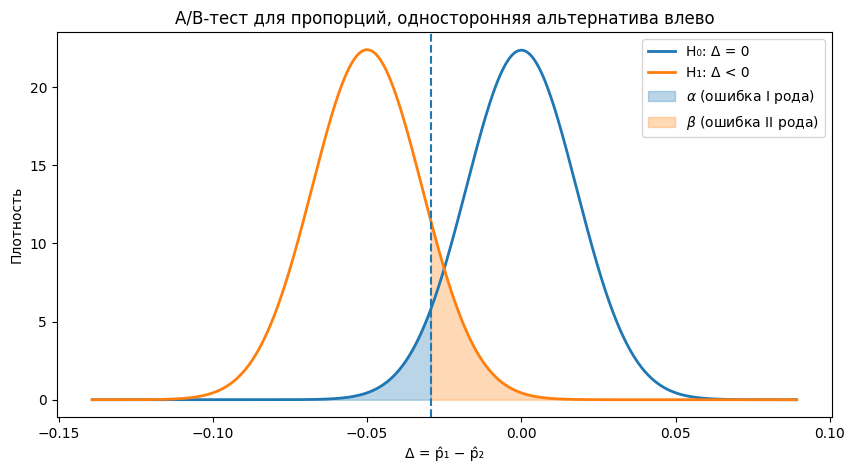

In [24]:
# Односторонняя альтернатива

z_one = norm.ppf(1 - alpha)
c = -z_one * SE_H0

plt.figure(figsize=(10, 5))

plt.plot(x, pdf_H0, label="H₀: Δ = 0", linewidth=2)
plt.plot(x, pdf_H1, label="H₁: Δ < 0", linewidth=2)

# Критическая область

plt.axvline(c, linestyle="--")

# Ошибка I рода (α)

alpha_color = "tab:blue"

plt.fill_between(
    x[x <= c],
    pdf_H0[x <= c],
    color=alpha_color,
    alpha=0.3,
    label=r"$\alpha$ (ошибка I рода)"
)

# Ошибка II рода (β)

beta_color = "tab:orange"

plt.fill_between(
    x[x > c],
    pdf_H1[x > c],
    color=beta_color,
    alpha=0.3,
    label=r"$\beta$ (ошибка II рода)"
)

plt.xlabel("Δ = p̂₁ − p̂₂")
plt.ylabel("Плотность")
plt.title("A/B-тест для пропорций, односторонняя альтернатива влево")
plt.legend()
plt.show()

In [30]:
ci1 = (p1 - z_two * s1, p1 + z_two * s1)
ci2 = (p2 - z_two * s2, p2 + z_two * s2)
print(f"Двусторонний ДИ для первой пропорции: ({ci1[0]:.3f}, {ci1[1]:.3f})")
print(f"Двусторонний ДИ для второй пропорции: ({ci2[0]:.3f}, {ci2[1]:.3f})")

Двусторонний ДИ для первой пропорции: (0.326, 0.374)
Двусторонний ДИ для второй пропорции: (0.375, 0.425)
